# Medication Recommender

In [13]:
from google.colab import drive
from pathlib import Path
import os

drive.mount('/content/drive')

PROJECT_DIR = Path('/content/drive/MyDrive/CMPE 256 - Project')
os.chdir(PROJECT_DIR)
print('current directory:', Path.cwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
current directory: /content/drive/.shortcut-targets-by-id/1aqZsPEz2Oa8kz7RWblFRGdYj1_wWzD8l/CMPE 256 - Project


## Prepare

In [ ]:
# this file is to prepare the dataset
# take raw tables and turn them into a format for modeling
# we will end up with 2 tables
# one is (patient, admission) -> patient features, admission features, history
# the other one is (patient, admission, drug) -> label

from pathlib import Path
import json

import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix, save_npz

DATA_DIR = Path("data/baseline_tables")
PROCESSED_DIR = Path("data/processed")
REFERENCE_DIR = Path("data/reference")

RANDOM_STATE = 42

# negative sampling
# model needs both positive and negative examples to learn what is good/bad
NEGATIVES_PER_POSITIVE = 10

# lab sources tables
LAB_SOURCES = [
    "chemistry",
    "complete_blood_count",
    "coagulation",
    "enzyme",
    "blood_differential",
    "cardiac_marker",
    "bg",
]


In [ ]:
# build diagnoses matrix
# use multi-hot encoding matrix
# returns:
# a sparse matrix (num_admissions, num_icd_codes)
# and a list of ICD codes, mapping column index to code
def build_current_dx_matrix(snapshot, diagnoses):
    # map each hadm_id to row number
    snap_hadms = snapshot["hadm_id"].tolist()
    hadm_to_row = {h: i for i, h in enumerate(snap_hadms)}

    dx = diagnoses.dropna(subset=["hadm_id", "icd_code"]).copy()
    dx["icd_code"] = dx["icd_code"].astype(str).str.strip()
    dx = dx[dx["icd_code"] != ""]
    dx = dx[dx["hadm_id"].isin(hadm_to_row)]
    dx = dx[["hadm_id", "icd_code"]].drop_duplicates()

    dx_codes = sorted(dx["icd_code"].unique())
    # map icd code to column number
    code_to_col = {code: i for i, code in enumerate(dx_codes)}

    # now build sparse matrix (multi-hot)
    rows = dx["hadm_id"].map(hadm_to_row).values
    cols = dx["icd_code"].map(code_to_col).values
    data = np.ones(len(dx), dtype=np.int8)
    matrix = csr_matrix((data, (rows, cols)), shape=(snapshot.shape[0], len(dx_codes)))
    return matrix, dx_codes


In [ ]:
# HISTORY (patient's past admissions)
# includes prior diagnoses, medications, procedures, number of admissions, days since last admission
# basically collapsing user history into a fixed size feature vector
def compute_history(snapshot, diagnoses, interactions, procedures, dx_codes, medications, proc_codes):
    dx_to_col = {c: i for i, c in enumerate(dx_codes)}
    med_to_col = {m: i for i, m in enumerate(medications)}
    proc_to_col = {c: i for i, c in enumerate(proc_codes)}

    n_rows = len(snapshot)
    num_prior_admissions = np.zeros(n_rows, dtype=int)
    days_since_last_admission = np.full(n_rows, np.nan)

    # per admission diagnosis/medication/procedure sets
    dx_clean = diagnoses.dropna(subset=["hadm_id", "icd_code"]).copy()
    dx_clean["icd_code"] = dx_clean["icd_code"].astype(str).str.strip()
    dx_clean = dx_clean[dx_clean["icd_code"] != ""]

    proc_clean = procedures.dropna(subset=["hadm_id", "icd_code"]).copy()
    proc_clean["icd_code"] = proc_clean["icd_code"].astype(str).str.strip()
    proc_clean = proc_clean[proc_clean["icd_code"] != ""]

    current_dx_by_hadm = {}
    for hadm_id, grp in dx_clean.groupby("hadm_id"):
        current_dx_by_hadm[hadm_id] = set(grp["icd_code"])

    current_meds_by_hadm = {}
    for hadm_id, grp in interactions.groupby("hadm_id"):
        current_meds_by_hadm[hadm_id] = set(grp["medication"])

    current_proc_by_hadm = {}
    for hadm_id, grp in proc_clean.groupby("hadm_id"):
        current_proc_by_hadm[hadm_id] = set(grp["icd_code"])

    prior_dx_rows, prior_dx_cols = [], []
    prior_med_rows, prior_med_cols = [], []
    prior_proc_rows, prior_proc_cols = [], []

    # go through each patient's admissions in chronological order
    # and build their history
    for _, group in snapshot.groupby("subject_id", sort=False):
        seen_dx = set()
        seen_meds = set()
        seen_procs = set()
        last_admit_time = None
        prior_count = 0

        for row in group.itertuples():
            i = row.Index
            num_prior_admissions[i] = prior_count

            # days_since_last_admission
            if last_admit_time is not None:
                gap = (row.admittime - last_admit_time).days
                days_since_last_admission[i] = gap

            for code in seen_dx:
                if code in dx_to_col:
                    prior_dx_rows.append(i)
                    prior_dx_cols.append(dx_to_col[code])
            for med in seen_meds:
                if med in med_to_col:
                    prior_med_rows.append(i)
                    prior_med_cols.append(med_to_col[med])
            for code in seen_procs:
                if code in proc_to_col:
                    prior_proc_rows.append(i)
                    prior_proc_cols.append(proc_to_col[code])

            if row.hadm_id in current_dx_by_hadm:
                seen_dx.update(current_dx_by_hadm[row.hadm_id])
            if row.hadm_id in current_meds_by_hadm:
                seen_meds.update(current_meds_by_hadm[row.hadm_id])
            if row.hadm_id in current_proc_by_hadm:
                seen_procs.update(current_proc_by_hadm[row.hadm_id])
            last_admit_time = row.admittime
            prior_count += 1

    dx_data = np.ones(len(prior_dx_rows), dtype=np.int8)
    prior_dx_matrix = csr_matrix(
        (dx_data, (prior_dx_rows, prior_dx_cols)),
        shape=(n_rows, len(dx_codes)),
    )

    med_data = np.ones(len(prior_med_rows), dtype=np.int8)
    prior_med_matrix = csr_matrix(
        (med_data, (prior_med_rows, prior_med_cols)),
        shape=(n_rows, len(medications)),
    )

    proc_data = np.ones(len(prior_proc_rows), dtype=np.int8)
    prior_proc_matrix = csr_matrix(
        (proc_data, (prior_proc_rows, prior_proc_cols)),
        shape=(n_rows, len(proc_codes)),
    )

    history = pd.DataFrame(
        {
            "num_prior_admissions": num_prior_admissions,
            "days_since_last_admission": days_since_last_admission,
        },
        index=snapshot.index,
    )
    return history, prior_dx_matrix, prior_med_matrix, prior_proc_matrix


In [ ]:
# labs - just first value per admission for each test
def build_current_labs(snapshot, source):
    df = pd.read_csv(DATA_DIR / f"{source}.csv", low_memory=False)
    # drop labs not tied to admissions
    df = df.dropna(subset=["hadm_id"]).copy()
    df["hadm_id"] = df["hadm_id"].astype(int)
    df = df[df["hadm_id"].isin(set(snapshot["hadm_id"]))]
    df["charttime"] = pd.to_datetime(df["charttime"], errors="coerce")
    df = df.sort_values(["hadm_id", "charttime"])

    lab_cols = [c for c in df.columns if c not in ("hadm_id", "charttime")]

    first = df.groupby("hadm_id")[lab_cols].first()
    aligned = first.reindex(snapshot["hadm_id"])

    values = aligned.to_numpy(dtype=np.float32)
    flags = (~aligned.isna()).to_numpy(dtype=np.float32)
    return values, flags, lab_cols


# labs history
def compute_prior_labs(snapshot, current_values, current_flags):
    n_rows, n_cols = current_values.shape
    prior_values = np.full((n_rows, n_cols), np.nan, dtype=np.float32)
    prior_flags = np.zeros((n_rows, n_cols), dtype=np.float32)

    for _, group in snapshot.groupby("subject_id", sort=False):
        last_vals = np.full(n_cols, np.nan, dtype=np.float32)
        last_flags = np.zeros(n_cols, dtype=np.float32)
        for row in group.itertuples():
            i = row.Index
            prior_values[i] = last_vals
            prior_flags[i] = last_flags

            measured = current_flags[i] > 0
            last_vals[measured] = current_values[i][measured]
            last_flags[measured] = 1.0

    return prior_values, prior_flags


# build the label table for admission drug pairs (final interaction table)
# build negative samples for training
def make_label_table(snapshot, interactions):
    rng = np.random.default_rng(RANDOM_STATE)
    all_drugs = sorted(interactions["medication"].unique())

    positive_by_hadm = {}
    for hadm_id, grp in interactions.groupby("hadm_id"):
        positive_by_hadm[hadm_id] = set(grp["medication"])

    rows = []
    for hadm_id in snapshot["hadm_id"]:
        positive_drugs = positive_by_hadm[hadm_id]

        for drug in sorted(positive_drugs):
            rows.append({"hadm_id": hadm_id, "candidate_drug": drug, "label": 1})

        # sample negatives from drugs not given in this admission
        non_positive_drugs = [d for d in all_drugs if d not in positive_drugs]

        n_neg = min(NEGATIVES_PER_POSITIVE * len(positive_drugs), len(non_positive_drugs))
        negative_drugs = rng.choice(non_positive_drugs, size=n_neg, replace=False)

        for drug in sorted(negative_drugs):
            rows.append({"hadm_id": hadm_id, "candidate_drug": drug, "label": 0})

    return pd.DataFrame(rows)


In [ ]:
# === put everything together ===

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("loading raw tables...")
admissions = pd.read_csv(DATA_DIR / "admissions.csv", low_memory=False)
patients = pd.read_csv(DATA_DIR / "patients.csv", low_memory=False)
diagnoses = pd.read_csv(DATA_DIR / "diagnoses_icd.csv", low_memory=False)
emar = pd.read_csv(DATA_DIR / "emar.csv", low_memory=False)
procedures = pd.read_csv(DATA_DIR / "procedures_icd.csv", low_memory=False)
print("admissions:", len(admissions), "patients:", len(patients))
print("diagnoses:", len(diagnoses), "emar:", len(emar), "procedures:", len(procedures))


# creates (hadm_id, medication) foundation
# no matching hadm_id - means not tied to an admission
interactions = emar.dropna(subset=["hadm_id"]).copy()
interactions["hadm_id"] = interactions["hadm_id"].astype(int)

meds = interactions["medication"].fillna("")
meds = meds.astype(str).str.strip()
interactions["medication"] = meds
interactions = interactions[interactions["medication"] != ""]

# for each admission, what drugs were administered (no dups)
interactions = interactions[["hadm_id", "medication"]].drop_duplicates()
interactions = interactions.reset_index(drop=True)

# normalize medication names
drug_to_ingredient = pd.read_csv(REFERENCE_DIR / "drug_to_ingredient.csv")
d2i = dict(zip(drug_to_ingredient["drug"], drug_to_ingredient["ingredient_name"]))
interactions["medication"] = interactions["medication"].map(d2i).fillna(interactions["medication"])
interactions = interactions.drop_duplicates().reset_index(drop=True)

print("interactions:", len(interactions))
print("Top 20 medications after normalization:")
print(interactions["medication"].value_counts().head(20))


# start by joining patients/admissions, building basic blocks
# one row per admission
# patient is an easy merge into admissions
snapshot = admissions.merge(patients, on="subject_id", how="left")
snapshot["admittime"] = pd.to_datetime(snapshot["admittime"])

# get age, we need to calculate this because of how MIMIC shuffles data
snapshot["age_at_admission"] = (
    snapshot["anchor_age"] + snapshot["admittime"].dt.year - snapshot["anchor_year"]
)
snapshot = snapshot.drop(columns=["anchor_age", "anchor_year"])

# remove admissions that don't have any medication records (useless to us)
valid_hadms = set(interactions["hadm_id"])
snapshot = snapshot[snapshot["hadm_id"].isin(valid_hadms)]

# sort so we can create user history later.
snapshot = snapshot.sort_values(["subject_id", "admittime", "hadm_id"])
snapshot = snapshot.reset_index(drop=True)
print("snapshot:", snapshot.shape)

# normalized diagnosis/prcedures
dx_map = pd.read_csv(REFERENCE_DIR / "dx_ccsr_map.csv", dtype=str)
proc_map = pd.read_csv(REFERENCE_DIR / "proc_ccs_map.csv", dtype=str)
diagnoses_norm = (
    diagnoses.assign(icd_version=diagnoses["icd_version"].astype(str))
    .merge(dx_map, on=["icd_code", "icd_version"], how="inner")
    [["hadm_id", "ccsr_category"]].rename(columns={"ccsr_category": "icd_code"})
)
procedures_norm = (
    procedures.assign(icd_version=procedures["icd_version"].astype(str))
    .merge(proc_map, on=["icd_code", "icd_version"], how="inner")
    [["hadm_id", "ccs_category"]].rename(columns={"ccs_category": "icd_code"})
)
print(f"dx: {diagnoses_norm['icd_code'].nunique()} CCSR categories, proc: {procedures_norm['icd_code'].nunique()} CCS categories")

print("building current dx matrix...")
current_dx_matrix, dx_codes = build_current_dx_matrix(snapshot, diagnoses_norm)
medications = sorted(interactions["medication"].unique())
print("dx codes:", len(dx_codes), "medications:", len(medications))

print("building current proc matrix...")
current_proc_matrix, proc_codes = build_current_dx_matrix(snapshot, procedures_norm)
print("proc codes:", len(proc_codes))

print("computing history features...")
history_features, prior_dx_matrix, prior_med_matrix, prior_proc_matrix = compute_history(
    snapshot, diagnoses_norm, interactions, procedures_norm, dx_codes, medications, proc_codes
)

patient_admission_snapshot = pd.concat([snapshot, history_features], axis=1)

# charlson, 1 to 1 rows with admissions
print("merging charlson...")
charlson = pd.read_csv(DATA_DIR / "charlson.csv", low_memory=False)
charlson = charlson.drop_duplicates("hadm_id")
patient_admission_snapshot = patient_admission_snapshot.merge(
    charlson, on="hadm_id", how="left"
)

# services: last current service per admission
print("merging services...")
services = pd.read_csv(DATA_DIR / "services.csv", low_memory=False)
services = services.sort_values("transfertime")
services = services.drop_duplicates("hadm_id", keep="last")
services = services[["hadm_id", "curr_service"]]
patient_admission_snapshot = patient_admission_snapshot.merge(
    services, on="hadm_id", how="left"
)

# labs
print("building lab matrices...")
lab_cols_by_source = {}
for source in LAB_SOURCES:
    print(f"  {source}...")
    current_v, current_f, lab_cols = build_current_labs(snapshot, source)
    prior_v, prior_f = compute_prior_labs(snapshot, current_v, current_f)
    np.savez_compressed(PROCESSED_DIR / f"current_{source}_labs.npz", values=current_v, flags=current_f)
    np.savez_compressed(PROCESSED_DIR / f"prior_{source}_labs.npz", values=prior_v, flags=prior_f)
    lab_cols_by_source[source] = lab_cols

print("making label table...")
admission_drug_labels = make_label_table(snapshot, interactions)
print("label rows:", len(admission_drug_labels))
admission_drug_labels.to_csv(PROCESSED_DIR / "admission_drug_labels.csv", index=False)


# save everything

patient_admission_snapshot.to_csv(PROCESSED_DIR / "patient_admission_snapshot.csv", index=False)
save_npz(PROCESSED_DIR / "current_dx_matrix.npz", current_dx_matrix)
save_npz(PROCESSED_DIR / "prior_dx_matrix.npz", prior_dx_matrix)
save_npz(PROCESSED_DIR / "prior_med_matrix.npz", prior_med_matrix)
save_npz(PROCESSED_DIR / "current_proc_matrix.npz", current_proc_matrix)
save_npz(PROCESSED_DIR / "prior_proc_matrix.npz", prior_proc_matrix)

charlson_cols = [c for c in charlson.columns if c != "hadm_id"]
metadata = {
    "dx_codes": dx_codes,
    "medications": medications,
    "proc_codes": proc_codes,
    "lab_sources": lab_cols_by_source,
    "charlson_cols": charlson_cols,
    "negatives_per_positive": NEGATIVES_PER_POSITIVE,
    "random_state": RANDOM_STATE,
}
with open(PROCESSED_DIR / "feature_metadata.json", "w") as fp:
    json.dump(metadata, fp, indent=2)

print("done")


loading raw tables...
admissions: 546028 patients: 364627
diagnoses: 6364488 emar: 28419780 procedures: 859655
interactions: 4053455
Top 20 medications after normalization:
medication
acetaminophen               192765
heparin                     143706
docusate                    108539
oxycodone                    92038
aspirin                      90438
sennosides, USP              85439
ondansetron                  80641
potassium chloride           76638
hydromorphone                71656
metoprolol                   71532
magnesium sulfate            70395
insulin lispro               69311
atorvastatin                 63949
furosemide                   58417
lorazepam                    57907
omeprazole                   54393
pantoprazole                 52196
polyethylene glycol 3350     50203
vancomycin                   49250
gabapentin                   45393
Name: count, dtype: int64
snapshot: (289685, 11)
dx: 539 CCSR categories, proc: 231 CCS categories
building current 

## EDA

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import load_npz

DATA_DIR = Path("data/baseline_tables")
PROCESSED_DIR = Path("data/processed")

LAB_SOURCES = [
    "chemistry",
    "complete_blood_count",
    "coagulation",
    "enzyme",
    "blood_differential",
    "cardiac_marker",
    "bg",
]


# === DATA CHECKS SECTION ===

print("=" * 60)
print("DATA CHECKS")
print("=" * 60)

snapshot_path = PROCESSED_DIR / "patient_admission_snapshot.csv"
labels_path = PROCESSED_DIR / "admission_drug_labels.csv"
matrix_files = {
    "current_dx": PROCESSED_DIR / "current_dx_matrix.npz",
    "prior_dx": PROCESSED_DIR / "prior_dx_matrix.npz",
    "prior_med": PROCESSED_DIR / "prior_med_matrix.npz",
    "current_proc": PROCESSED_DIR / "current_proc_matrix.npz",
    "prior_proc": PROCESSED_DIR / "prior_proc_matrix.npz",
}

# run prepare.py before running

# load processed tables
snapshot = pd.read_csv(snapshot_path, low_memory=False)
n_snap = len(snapshot)
print("snapshot loaded: %d rows" % n_snap)

labels = None
if labels_path.exists():
    labels = pd.read_csv(labels_path, low_memory=False)
    print(f"labels loaded: {len(labels):,} rows")
else:
    print(f"missing {labels_path}")

# check encoded features
missing_matrices = [name for name, path in matrix_files.items() if not path.exists()]

if missing_matrices:
    print(f"missing matrices: {missing_matrices}")
else:
    # all matrix should have same rows
    row_counts_match = True
    for name, p in matrix_files.items():
        mat = load_npz(p)
        if mat.shape[0] != n_snap:
            row_counts_match = False
            print(f"  row count mismatch: {name} has {mat.shape[0]} rows, snapshot has {n_snap}")
    print(f"snapshot/matrix row counts match: {row_counts_match}")

# interactions table
if labels is not None:
    hadm_ids_match = labels["hadm_id"].isin(snapshot["hadm_id"]).all()
    duplicate_pairs = labels.duplicated(["hadm_id", "candidate_drug"]).sum()
    pair_label_counts = labels.groupby(["hadm_id", "candidate_drug"])["label"].nunique()
    conflict_count = (pair_label_counts > 1).sum()
    print(f"all label hadm_id values exist in snapshot: {hadm_ids_match}")
    print(f"duplicate (hadm_id, candidate_drug) rows: {duplicate_pairs:,}")
    print(f"admission-drug label conflicts: {conflict_count:,}")


DATA CHECKS
snapshot loaded: 289685 rows
labels loaded: 44,588,005 rows
snapshot/matrix row counts match: True
all label hadm_id values exist in snapshot: True
duplicate (hadm_id, candidate_drug) rows: 0
admission-drug label conflicts: 0


RAW TABLES
admissions: 546,028 rows
patients: 364,627 rows
diagnoses: 6,364,488 rows
emar: 28,419,780 rows
unique patients in admissions: 223,452
unique admissions in emar: 290,076

admissions per patient:
count    223452.00
mean          2.44
std           3.57
min           1.00
25%           1.00
50%           1.00
75%           3.00
max         238.00
single-visit patients: 123,289
multi-visit patients: 100,163

diagnoses per admission (raw):
count    545497.00
mean         11.67
std           7.63
min           1.00
25%           6.00
50%          10.00
75%          16.00
max          57.00

emar rows per admission:
count    290076.00
mean         94.58
std         190.94
min           1.00
25%          14.00
50%          42.00
75%         102.00
max       19205.00


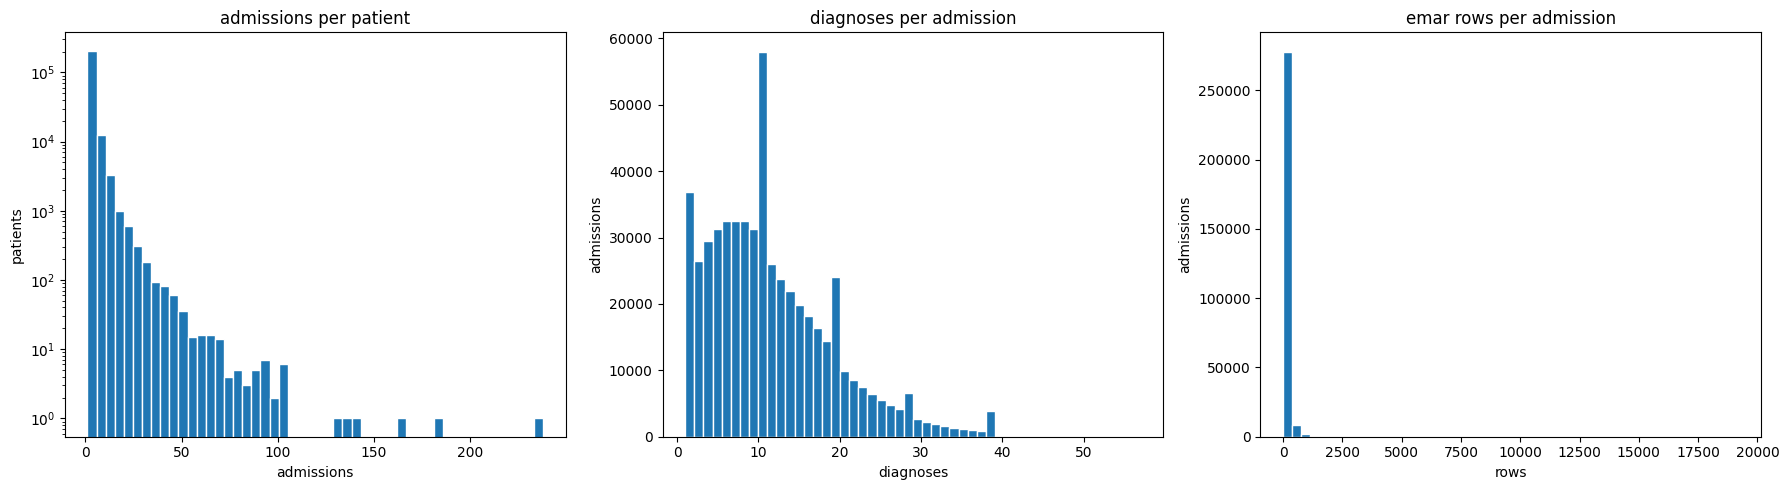

In [ ]:
# === RAW TABLES SECTION ===

print("=" * 60)
print("RAW TABLES")
print("=" * 60)

# these are raw tables, before processing
admissions = pd.read_csv(DATA_DIR / "admissions.csv", low_memory=False)
patients = pd.read_csv(DATA_DIR / "patients.csv", low_memory=False)
diagnoses = pd.read_csv(DATA_DIR / "diagnoses_icd.csv", low_memory=False)
emar = pd.read_csv(DATA_DIR / "emar.csv", low_memory=False)

# row counts
print(f"admissions: {len(admissions):,} rows")
print(f"patients: {len(patients):,} rows")
print(f"diagnoses: {len(diagnoses):,} rows")
print(f"emar: {len(emar):,} rows")

# unique ids
print(f"unique patients in admissions: {admissions['subject_id'].nunique():,}")
# how many admissions tied to emar medications
print(f"unique admissions in emar: {emar['hadm_id'].nunique():,}")

# admissions per patient (cold start)
admissions_per_patient = admissions.groupby("subject_id").size()
print("\nadmissions per patient:")
desc = admissions_per_patient.describe().round(2)
print(desc.to_string())
single_visit = (admissions_per_patient == 1).sum()
multi_visit = (admissions_per_patient > 1).sum()
print(f"single-visit patients: {single_visit:,}")
print(f"multi-visit patients: {multi_visit:,}")

# diagnoses per admission
dx_per_admission_raw = diagnoses.groupby("hadm_id").size()
print("\ndiagnoses per admission (raw):")
desc = dx_per_admission_raw.describe().round(2)
print(desc.to_string())

# medication per admission
# no medication per admission, because of dups (since raw tables)
emar_per_admission = emar.groupby("hadm_id").size()
print("\nemar rows per admission:")
desc = emar_per_admission.describe().round(2)
print(desc.to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(admissions_per_patient, bins=50, edgecolor="white")
axes[0].set_title("admissions per patient")
axes[0].set_xlabel("admissions")
axes[0].set_ylabel("patients")
axes[0].set_yscale("log")

axes[1].hist(dx_per_admission_raw, bins=50, edgecolor="white")
axes[1].set_title("diagnoses per admission")
axes[1].set_xlabel("diagnoses")
axes[1].set_ylabel("admissions")

axes[2].hist(emar_per_admission, bins=50, edgecolor="white")
axes[2].set_title("emar rows per admission")
axes[2].set_xlabel("rows")
axes[2].set_ylabel("admissions")

plt.tight_layout()
plt.show()


FEATURE TABLE
snapshot rows (admissions kept): 289,685
unique patients in snapshot: 137,162

age at admission:
count    289685.0
mean         60.9
std          18.6
min          18.0
25%          49.0
50%          63.0
75%          75.0
max         106.0

num_prior_admissions:
count    289685.00
mean          2.18
std           4.61
min           0.00
25%           0.00
50%           1.00
75%           2.00
max          88.00
first-visit (cold-start) admissions: 137,162 (47.3%)

days_since_last_admission (warm-start only):
count    152523.0
mean        271.1
std         431.0
min           0.0
25%          23.0
50%          80.0
75%         318.0
max        3157.0

charlson_comorbidity_index:
count    289685.00
mean          3.99
std           3.12
min           0.00
25%           1.00
50%           4.00
75%           6.00
max          21.00
admissions with charlson row: 289,685 (100.0%)

curr_service coverage: 289,669 (100.0%)
top services:
curr_service
MED      139234
CMED      27528

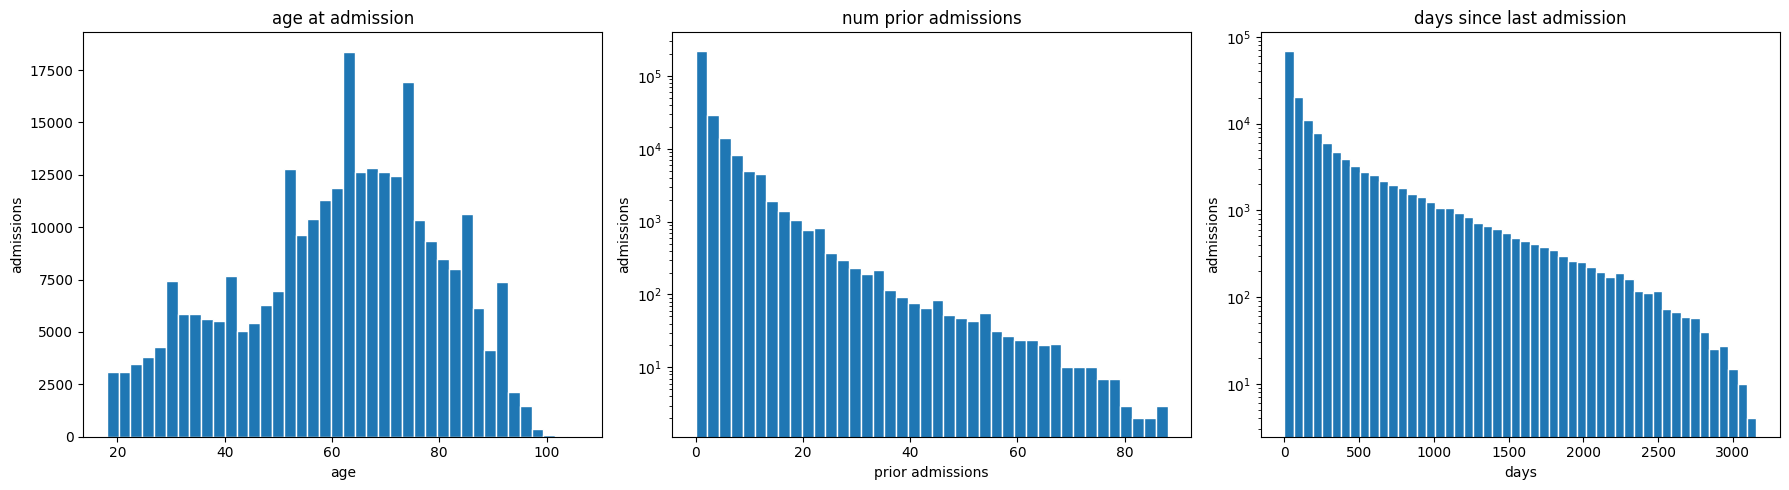

In [ ]:
# === Feature Table ===
# this section is after we merged, on the feature table
# we have things added like age, history features, etc.

print("=" * 60)
print("FEATURE TABLE")
print("=" * 60)

# size after filtering to admissions with medications
print(f"snapshot rows (admissions kept): {len(snapshot):,}")
print(f"unique patients in snapshot: {snapshot['subject_id'].nunique():,}")

# Age
print("\nage at admission:")
age_desc = snapshot["age_at_admission"].describe().round(1)
print(age_desc.to_string())

# patient history, cold start admissions
print("\nnum_prior_admissions:")
prior_desc = snapshot["num_prior_admissions"].describe().round(2)
print(prior_desc.to_string())
first_visit = (snapshot["num_prior_admissions"] == 0).sum()
pct = first_visit / len(snapshot)
print(f"first-visit (cold-start) admissions: {first_visit:,} ({pct:.1%})")

# days between this and the most recent last admission
gap = snapshot["days_since_last_admission"].dropna()
print("\ndays_since_last_admission (warm-start only):")
gap_desc = gap.describe().round(1)
print(gap_desc.to_string())

# charlson
cci = snapshot["charlson_comorbidity_index"]
print("\ncharlson_comorbidity_index:")
print(cci.describe().round(2).to_string())
print(f"admissions with charlson row: {cci.notna().sum():,} ({cci.notna().mean():.1%})")

# services (last service)
svc = snapshot["curr_service"]
print(f"\ncurr_service coverage: {svc.notna().sum():,} ({svc.notna().mean():.1%})")
print("top services:")
print(svc.value_counts().head(10).to_string())

# Three plots: age dist, prior-admission count (log y because heavy
# tail), and the readmission gap distribution.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(snapshot["age_at_admission"].dropna(), bins=40, edgecolor="white")
axes[0].set_title("age at admission")
axes[0].set_xlabel("age")
axes[0].set_ylabel("admissions")

axes[1].hist(snapshot["num_prior_admissions"], bins=40, edgecolor="white")
axes[1].set_title("num prior admissions")
axes[1].set_xlabel("prior admissions")
axes[1].set_ylabel("admissions")
axes[1].set_yscale("log")

axes[2].hist(
    snapshot["days_since_last_admission"].dropna(),
    bins=50,
    edgecolor="white",
)
axes[2].set_title("days since last admission")
axes[2].set_xlabel("days")
axes[2].set_ylabel("admissions")
axes[2].set_yscale("log")

plt.tight_layout()
plt.show()


In [ ]:
# === Sparse Matrices ===
# this section is aggregated multi-hot features
# diagnoses, medication, labs, procedures
print("\n" + "=" * 60)
print("Sparse matrices")
print("=" * 60)

missing = [name for name, p in matrix_files.items() if not p.exists()]

if missing:
    print(f"missing matrices: {missing}. Run prepare.py first. Skipping section 3.")
else:
    for name, p in matrix_files.items():
        # print stats
        # is cur values, history values mostly populated or empty
        mat = load_npz(p)
        per_row = np.asarray(mat.sum(axis=1)).flatten()

        density = mat.nnz / (mat.shape[0] * mat.shape[1])

        print(f"\n{name}: shape={mat.shape}, nnz={mat.nnz:,}, density={density:.4%}")
        print("  per-admission counts: mean=%.1f, median=%.0f, max=%d" % (per_row.mean(), np.median(per_row), per_row.max()))
        zero_rows = (per_row == 0).sum()
        print(f"  rows with zero entries: {zero_rows:,}")



Sparse matrices

current_dx: shape=(289685, 537), nnz=4,273,782, density=2.7473%
  per-admission counts: mean=14.8, median=14, max=54
  rows with zero entries: 100

prior_dx: shape=(289685, 537), nnz=4,334,929, density=2.7866%
  per-admission counts: mean=15.0, median=6, max=145
  rows with zero entries: 137,175

prior_med: shape=(289685, 2255), nnz=4,268,324, density=0.6534%
  per-admission counts: mean=14.7, median=4, max=164
  rows with zero entries: 137,162

current_proc: shape=(289685, 226), nnz=355,839, density=0.5435%
  per-admission counts: mean=1.2, median=1, max=23
  rows with zero entries: 142,093

prior_proc: shape=(289685, 226), nnz=485,995, density=0.7423%
  per-admission counts: mean=1.7, median=0, max=37
  rows with zero entries: 178,245



Interaction Table
label rows: 44588005
positives: 4,053,455
negatives: 40,534,550
unique candidate drugs: 2,255

positives per admission:
count    289685.00
mean         13.99
std           9.57
min           1.00
25%           7.00
50%          12.00
75%          19.00
max         119.00

top 20 drugs by admissions administered:
candidate_drug
acetaminophen               192765
heparin                     143706
docusate                    108539
oxycodone                    92038
aspirin                      90438
sennosides, USP              85439
ondansetron                  80641
potassium chloride           76638
hydromorphone                71656
metoprolol                   71532
magnesium sulfate            70395
insulin lispro               69311
atorvastatin                 63949
furosemide                   58417
lorazepam                    57907
omeprazole                   54393
pantoprazole                 52196
polyethylene glycol 3350     50203
vancomycin            

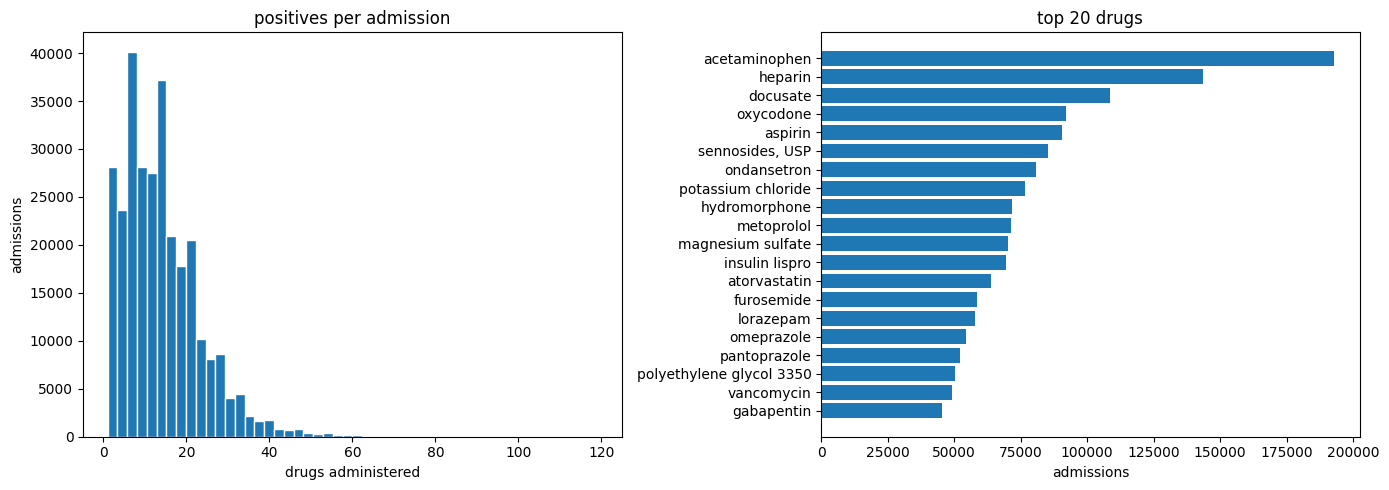

In [ ]:
# === Interaction Table ===
print("\n" + "=" * 60)
print("Interaction Table")
print("=" * 60)

if labels is None:
    print(f"missing {labels_path}. Run prepare.py first. Skipping section 4.")
else:
    n_labels = len(labels)
    n_pos = (labels["label"] == 1).sum()
    n_neg = (labels["label"] == 0).sum()
    n_drugs = labels["candidate_drug"].nunique()
    print("label rows: %d" % n_labels)
    print(f"positives: {n_pos:,}")
    print(f"negatives: {n_neg:,}")
    print(f"unique candidate drugs: {n_drugs:,}")

    # drugs per admission
    positives = labels[labels["label"] == 1]
    pos_per_admission = positives.groupby("hadm_id").size()
    print("\npositives per admission:")
    pos_desc = pos_per_admission.describe().round(2)
    print(pos_desc.to_string())

    # most popular drugs
    drug_popularity = positives["candidate_drug"].value_counts()
    print("\ntop 20 drugs by admissions administered:")
    print(drug_popularity.head(20).to_string())

    # what share of administrations are from the popular drugs
    # higher means stronger popularity bias, which means it may be harder to beat.
    n_unique_drugs = len(drug_popularity)
    top_10pct = max(1, int(n_unique_drugs * 0.1))
    share = drug_popularity.head(top_10pct).sum() / drug_popularity.sum()
    print(f"\ntop 10% of drugs ({top_10pct:,}) cover {share:.1%} of administrations")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(pos_per_admission, bins=50, edgecolor="white")
    axes[0].set_title("positives per admission")
    axes[0].set_xlabel("drugs administered")
    axes[0].set_ylabel("admissions")

    top20 = drug_popularity.head(20)
    axes[1].barh(top20.index[::-1], top20.values[::-1])
    axes[1].set_title("top 20 drugs")
    axes[1].set_xlabel("admissions")

    plt.tight_layout()
    plt.show()


In [ ]:
# === Lab Matrices ===
# dense float matrices, one current + one prior per source
# values are NaN where not measured, flags are 0/1
print("\n" + "=" * 60)
print("Lab matrices")
print("=" * 60)

for source in LAB_SOURCES:
    cur_path = PROCESSED_DIR / f"current_{source}_labs.npz"
    pri_path = PROCESSED_DIR / f"prior_{source}_labs.npz"
    if not cur_path.exists() or not pri_path.exists():
        print(f"\n{source}: missing files, skipping")
        continue

    cur = np.load(cur_path)
    pri = np.load(pri_path)
    cur_vals = cur["values"]
    cur_flags = cur["flags"]
    pri_flags = pri["flags"]

    n_cols = cur_vals.shape[1]
    cur_coverage = (cur_flags.sum(axis=1) > 0).mean()
    pri_coverage = (pri_flags.sum(axis=1) > 0).mean()
    per_col_cur = cur_flags.mean(axis=0)

    print(f"\n{source}: shape={cur_vals.shape}, cols={n_cols}")
    print(f"  current: admissions with any measurement {cur_coverage:.1%}")
    print(f"  prior:   admissions with any measurement {pri_coverage:.1%}")
    print(f"  per-column measured rate (current): min={per_col_cur.min():.1%}, "
          f"mean={per_col_cur.mean():.1%}, max={per_col_cur.max():.1%}")



Lab matrices

chemistry: shape=(289685, 12), cols=12
  current: admissions with any measurement 81.3%
  prior:   admissions with any measurement 48.1%
  per-column measured rate (current): min=1.8%, mean=62.6%, max=80.9%

complete_blood_count: shape=(289685, 10), cols=10
  current: admissions with any measurement 83.0%
  prior:   admissions with any measurement 48.6%
  per-column measured rate (current): min=0.0%, mean=73.8%, max=83.0%

coagulation: shape=(289685, 6), cols=6
  current: admissions with any measurement 55.6%
  prior:   admissions with any measurement 39.3%
  per-column measured rate (current): min=0.3%, mean=29.0%, max=55.0%

enzyme: shape=(289685, 11), cols=11
  current: admissions with any measurement 50.7%
  prior:   admissions with any measurement 37.5%
  per-column measured rate (current): min=1.2%, mean=21.9%, max=44.9%

blood_differential: shape=(289685, 16), cols=16
  current: admissions with any measurement 81.8%
  prior:   admissions with any measurement 48.2%

## Training

In [14]:
!USE_OPENMP=1 pip install lightfm-next --no-binary lightfm-next
!pip install implicit

In [15]:
import lightfm._lightfm_fast_openmp
print("openmp ok")

openmp ok


In [16]:
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["OMP_NUM_THREADS"] = "8"

import time
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix, diags, hstack, load_npz
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MaxAbsScaler

from lightgbm import Dataset, early_stopping, log_evaluation, train as lgb_train
from lightfm import LightFM
from implicit.als import AlternatingLeastSquares

PROCESSED_DIR = Path("data/processed")
MODELS_DIR = Path("data/models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACTS_PATH = MODELS_DIR / "artifacts.pkl"

LAB_SOURCES = [
    "chemistry",
    "complete_blood_count",
    "coagulation",
    "enzyme",
    "blood_differential",
    "cardiac_marker",
    "bg",
]

K = 20
TEST_SIZE = 0.20
TOP_N_SAVED = 100
RANDOM_STATE = 42

In [17]:
# split by patient, so that same patient doesn't show up in train and test
# this would cause leakage, so that all history stays on one side
def split_by_patient(features):
    rng = np.random.default_rng(RANDOM_STATE)
    subjects = features["subject_id"].drop_duplicates().to_numpy().copy()
    rng.shuffle(subjects)

    n_test = int(len(subjects) * TEST_SIZE)
    test_subjects = set(subjects[:n_test].tolist())
    train_subjects = set(subjects[n_test:].tolist())

    train_hadm_ids = features.loc[features["subject_id"].isin(train_subjects), "hadm_id"]
    test_hadm_ids = features.loc[features["subject_id"].isin(test_subjects), "hadm_id"]
    return set(train_hadm_ids), set(test_hadm_ids)


In [18]:
# precision@k, recall@k, and ndcg@k
# we are predicting hadm_id -> ranked list of medications
# our test is hadm_id -> medications actually administered
def evaluate(predictions, ground_truth):
    p_list, r_list, n_list = [], [], []

    for hadm_id, true_drugs in ground_truth.items():
        top_k = predictions.get(hadm_id, [])[:K]
        hits = set(top_k) & true_drugs

        # out of the K recommended drugs, how many were correct
        p_list.append(len(hits) / K)
        # out of the drugs actually given, how many did we include
        r_list.append(len(hits) / len(true_drugs))
        # rewards putting correct drugs higher
        n_list.append(ndcg_at_k(top_k, true_drugs))

    return np.mean(p_list), np.mean(r_list), np.mean(n_list)

In [19]:
# ndcg@k for an admission
def ndcg_at_k(preds, true_drugs):
    dcg = 0.0
    for i, drug in enumerate(preds):
        if drug in true_drugs:
            dcg += 1.0 / np.log2(i + 2)

    # ideal is if our order is all right
    ideal_hits = min(len(true_drugs), K)
    ideal_dcg = sum(1.0 / np.log2(r + 1) for r in range(1, ideal_hits + 1))

    if ideal_dcg == 0:
        return 0.0
    return dcg / ideal_dcg

In [20]:
# for the feature table
def build_dense_feature_matrix(features):
    drop_cols = ["subject_id", "hadm_id", "admittime"]
    dense = features.drop(columns=drop_cols, errors="ignore")
    dense = pd.get_dummies(dense, dummy_na=True).fillna(0)
    return csr_matrix(dense.to_numpy(dtype=np.float32))


In [21]:
# fill missing values with median of train
def impute_labs(values, train_rows):
    out = values.copy()
    medians = np.nanmedian(values[train_rows], axis=0)
    medians = np.where(np.isnan(medians), 0.0, medians)
    for j in range(out.shape[1]):
        mask = np.isnan(out[:, j])
        out[mask, j] = medians[j]
    return out


def load_lab_source(source, train_rows):
    current = np.load(PROCESSED_DIR / f"current_{source}_labs.npz")
    prior = np.load(PROCESSED_DIR / f"prior_{source}_labs.npz")

    current_values = impute_labs(current["values"], train_rows)
    prior_values = impute_labs(prior["values"], train_rows)
    block = np.concatenate(
        [current_values, current["flags"], prior_values, prior["flags"]], axis=1
    )
    return csr_matrix(block.astype(np.float32))


# normalize and scale
def field_normalize(mat):
    nnz = np.diff(mat.indptr).astype(np.float32)
    nnz[nnz == 0] = 1.0
    return (diags(1.0 / nnz) @ mat).astype(np.float32)


def scale_train_fit(mat, train_rows):
    scaler = MaxAbsScaler()
    scaler.fit(mat[train_rows])
    return scaler.transform(mat).astype(np.float32)


# add in the dense matrices
def build_full_feature_matrix(features, train_rows):
    current_dx = field_normalize(load_npz(PROCESSED_DIR / "current_dx_matrix.npz"))
    prior_dx = field_normalize(load_npz(PROCESSED_DIR / "prior_dx_matrix.npz"))
    prior_med = field_normalize(load_npz(PROCESSED_DIR / "prior_med_matrix.npz"))
    current_proc = field_normalize(load_npz(PROCESSED_DIR / "current_proc_matrix.npz"))
    prior_proc = field_normalize(load_npz(PROCESSED_DIR / "prior_proc_matrix.npz"))
    dense = scale_train_fit(build_dense_feature_matrix(features), train_rows)

    blocks = [current_dx, prior_dx, prior_med, current_proc, prior_proc, dense]
    for source in LAB_SOURCES:
        blocks.append(scale_train_fit(load_lab_source(source, train_rows), train_rows))
    out = hstack(blocks, format="csr")
    out.indptr = out.indptr.astype(np.int64)
    out.indices = out.indices.astype(np.int64)
    return out


In [22]:
print("loading processed tables...")
features = pd.read_csv(PROCESSED_DIR / "patient_admission_snapshot.csv", low_memory=False)
labels = pd.read_csv(PROCESSED_DIR / "admission_drug_labels.csv", low_memory=False)

# handle type
features["admittime"] = pd.to_datetime(features["admittime"])
features["hadm_id"] = features["hadm_id"].astype(int)
labels["hadm_id"] = labels["hadm_id"].astype(int)

interactions = labels[labels["label"] == 1].rename(columns={"candidate_drug": "medication"})

train_ids, test_ids = split_by_patient(features)

train_interactions = interactions[interactions["hadm_id"].isin(train_ids)]
test_interactions = interactions[interactions["hadm_id"].isin(test_ids)]

ground_truth = {}
for hadm_id, grp in test_interactions.groupby("hadm_id"):
    ground_truth[hadm_id] = set(grp["medication"])

top_meds = train_interactions["medication"].value_counts().index.tolist()

print("admissions:", len(features), "train:", len(train_ids), "test:", len(test_ids))

hadm_ids = features["hadm_id"].to_numpy()
hadm_to_row = {h: i for i, h in enumerate(hadm_ids)}

train_rows = np.where(features["hadm_id"].isin(train_ids).to_numpy())[0]
test_rows = np.where(features["hadm_id"].isin(test_ids).to_numpy())[0]
train_hadm = hadm_ids[train_rows]
test_hadm = hadm_ids[test_rows]

print("building feature matrix...")
feature_matrix = build_full_feature_matrix(features, train_rows)

med_vocab = np.array(sorted(train_interactions["medication"].unique()))
med_to_col = {med: i for i, med in enumerate(med_vocab)}
med_ids = np.arange(len(med_vocab), dtype=np.int32)
n_meds = len(med_vocab)

def trim_preds(preds):
    return {h: list(v)[:TOP_N_SAVED] for h, v in preds.items()}


metrics = {}
all_preds = {}


def save_artifacts():
    with open(ARTIFACTS_PATH, "wb") as f:
        pickle.dump({
            "predictions": all_preds,
            "metrics": metrics,
            "ground_truth": ground_truth,
            "train_ids": train_ids,
            "test_ids": test_ids,
        }, f)


# save stuff needed for app.py
def save_pickle(name, obj):
    with open(MODELS_DIR / name, "wb") as f:
        pickle.dump(obj, f)

loading processed tables...
admissions: 289685 train: 232456 test: 57229
building feature matrix...


/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:1233: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


In [ ]:
# ========== MODEL 1: overall medication popularity ==========

# same list to every admission
popularity_preds = {}
for hadm_id in ground_truth:
    popularity_preds[hadm_id] = top_meds
p, r, n = evaluate(popularity_preds, ground_truth)
print(f"\npopularity  P@{K}={p:.4f}  R@{K}={r:.4f}  NDCG@{K}={n:.4f}")

metrics["popularity"] = (p, r, n)
all_preds["popularity"] = trim_preds(popularity_preds)
save_artifacts()

# shared data for all model saves
save_pickle("shared.pkl", {
    "feature_matrix": feature_matrix,
    "med_vocab": med_vocab,
    "hadm_to_row": hadm_to_row,
    "med_to_col": med_to_col,
    "top_meds": top_meds,
    "n_meds": n_meds,
})



popularity  P@20=0.2724  R@20=0.4161  NDCG@20=0.4476
saved popularity to data/models/artifacts.pkl


In [ ]:
# ========== MODEL 2: KNN ==========

KNN_NEIGHBORS = 50
KNN_BATCH_SIZE = 500

t0 = time.time()
print("building full-feature KNN baseline...")
train_features = feature_matrix[train_rows]
test_features = feature_matrix[test_rows]

train_drugs_by_hadm = {}
for hadm_id, grp in train_interactions.groupby("hadm_id"):
    train_drugs_by_hadm[hadm_id] = list(grp["medication"])

drug_rows, drug_cols = [], []
for pos, hadm_id in enumerate(train_hadm):
    for drug in train_drugs_by_hadm.get(hadm_id, []):
        drug_rows.append(pos)
        drug_cols.append(med_to_col[drug])
train_drug_matrix = csr_matrix(
    (np.ones(len(drug_rows), dtype=np.float32), (drug_rows, drug_cols)),
    shape=(len(train_rows), n_meds),
)

knn_preds = {}
for start in range(0, len(test_rows), KNN_BATCH_SIZE):
    batch = test_features[start:start + KNN_BATCH_SIZE]
    sims = cosine_similarity(batch, train_features)

    for i, row_sims in enumerate(sims):
        hadm_id = test_hadm[start + i]
        top_idx = np.argpartition(row_sims, -KNN_NEIGHBORS)[-KNN_NEIGHBORS:]
        top_sims = row_sims[top_idx]
        pos_mask = top_sims > 0
        top_idx = top_idx[pos_mask]
        top_sims = top_sims[pos_mask]

        if len(top_idx) == 0:
            knn_preds[hadm_id] = top_meds
            continue

        drug_scores = np.asarray(top_sims @ train_drug_matrix[top_idx]).ravel()
        knn_preds[hadm_id] = med_vocab[np.argsort(drug_scores)[::-1]].tolist()

p, r, n = evaluate(knn_preds, ground_truth)
print(f"knn  P@{K}={p:.4f}  R@{K}={r:.4f}  NDCG@{K}={n:.4f}  ({time.time() - t0:.0f}s)")
metrics["knn"] = (p, r, n)
all_preds["knn"] = trim_preds(knn_preds)
save_artifacts()

save_pickle("knn.pkl", {
    "train_features": train_features,
    "train_drug_matrix": train_drug_matrix,
})

building full-feature KNN baseline...
knn  P@20=0.3260  R@20=0.5208  NDCG@20=0.5485  (8270s)
saved knn to data/models/artifacts.pkl


In [ ]:
# ========== MODEL 3: ALS ==========

ALS_FACTORS = 64  # latent factors for ALS
ALS_EPOCHS = 10
ALS_REG = 0.01

# all users/subjects in train
train_subjects = np.sort(
    features.loc[train_rows, "subject_id"].drop_duplicates().to_numpy()
)
# subject/med id to index mapping
subj_to_row = {subj: i for i, subj in enumerate(train_subjects)}

# build unique subject/med pairs
hadm_to_subj = features[["hadm_id", "subject_id"]]
patient_med_pairs = train_interactions.merge(hadm_to_subj, on="hadm_id", how="left")
patient_med_pairs = patient_med_pairs[["subject_id", "medication"]].drop_duplicates()

# subject-drug matrxi
# 1 means seen, 0 means not observed
subj_rows = patient_med_pairs["subject_id"].map(subj_to_row).to_numpy()
med_cols = patient_med_pairs["medication"].map(med_to_col).to_numpy()
patient_item_matrix = csr_matrix(
    (np.ones(len(patient_med_pairs), dtype=np.float32), (subj_rows, med_cols)),
    shape=(len(train_subjects), len(med_vocab)),
)

t0 = time.time()
print("training ALS baseline...")
als_model = AlternatingLeastSquares(
    factors=ALS_FACTORS,
    regularization=ALS_REG,
    iterations=ALS_EPOCHS,
    random_state=RANDOM_STATE,
)
als_model.fit(patient_item_matrix)

# uses prior med list to predict new medications
prior_med_matrix = load_npz(PROCESSED_DIR / "prior_med_matrix.npz")
all_prior_meds = np.array(sorted(interactions["medication"].unique()))

als_preds = {}
for row_idx, hadm_id in zip(test_rows, test_hadm):
    prior_indices = prior_med_matrix[row_idx].indices

    cols = []
    for idx in prior_indices:
        med = all_prior_meds[idx]
        if med in med_to_col:
            cols.append(med_to_col[med])

    if len(cols) == 0:
        als_preds[hadm_id] = top_meds
        continue

    user_items = csr_matrix(
        (np.ones(len(cols), dtype=np.float32),
         (np.zeros(len(cols), dtype=np.int32), np.array(cols, dtype=np.int32))),
        shape=(1, n_meds),
    )
    ids, _ = als_model.recommend(
        0, user_items, N=n_meds,
        recalculate_user=True,
        filter_already_liked_items=False,
    )
    als_preds[hadm_id] = med_vocab[ids].tolist()

p, r, n = evaluate(als_preds, ground_truth)
print(f"als  P@{K}={p:.4f}  R@{K}={r:.4f}  NDCG@{K}={n:.4f}  ({time.time() - t0:.0f}s)")
metrics["als"] = (p, r, n)
all_preds["als"] = trim_preds(als_preds)
save_artifacts()

training ALS baseline...


/usr/local/lib/python3.12/dist-packages/implicit/cpu/als.py:96: RuntimeWarning: OpenBLAS is configured to use 8 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


  0%|          | 0/10 [00:00<?, ?it/s]

als  P@20=0.2919  R@20=0.4519  NDCG@20=0.4660  (407s)
saved als to data/models/artifacts.pkl


In [ ]:
# ========== MODEL 4: LightFM ==========

LIGHTFM_FACTORS = 32
LIGHTFM_EPOCHS = 50
LIGHTFM_THREADS = 8
LIGHTFM_BATCH_SIZE = 500

# CF with matrix factorization but w/ all side features
# ALS only sees patient/med, so this works with a lot more context
admission_drug_pairs = train_interactions[["hadm_id", "medication"]].drop_duplicates()

# (admission, drug) interaction
interaction_rows, interaction_cols = [], []
for hadm_id, med in zip(
    admission_drug_pairs["hadm_id"], admission_drug_pairs["medication"]
):
    interaction_rows.append(hadm_to_row[hadm_id])
    interaction_cols.append(med_to_col[med])
lightfm_interactions = csr_matrix(
    (np.ones(len(interaction_rows), dtype=np.float32), (interaction_rows, interaction_cols)),
    shape=(len(features), len(med_vocab)),
)

# scaled, normalized features
lightfm_user_features = feature_matrix.copy()
lightfm_user_features.indptr = lightfm_user_features.indptr.astype(np.int32)
lightfm_user_features.indices = lightfm_user_features.indices.astype(np.int32)

t0 = time.time()
print("training LightFM baseline...")
lightfm_model = LightFM(
    no_components=LIGHTFM_FACTORS,
    loss="warp",
    random_state=RANDOM_STATE,
)
lightfm_model.fit(
    lightfm_interactions,
    user_features=lightfm_user_features,
    epochs=LIGHTFM_EPOCHS,
    num_threads=LIGHTFM_THREADS,
    verbose=True,
)

lightfm_preds = {}
for start in range(0, len(test_rows), LIGHTFM_BATCH_SIZE):
    batch_rows = test_rows[start:start + LIGHTFM_BATCH_SIZE]
    batch_hadm = test_hadm[start:start + LIGHTFM_BATCH_SIZE]

    user_ids = np.repeat(batch_rows, n_meds)
    item_ids = np.tile(med_ids, len(batch_rows))

    scores = lightfm_model.predict(
        user_ids, item_ids,
        user_features=lightfm_user_features,
        num_threads=LIGHTFM_THREADS,
    ).reshape(len(batch_rows), n_meds)

    for i, hadm_id in enumerate(batch_hadm):
        # sort highest first
        ranking = np.argsort(scores[i])[::-1]
        lightfm_preds[hadm_id] = med_vocab[ranking].tolist()

p, r, n = evaluate(lightfm_preds, ground_truth)
print(f"lightfm  P@{K}={p:.4f}  R@{K}={r:.4f}  NDCG@{K}={n:.4f}  ({time.time() - t0:.0f}s)")

metrics["lightfm"] = (p, r, n)
all_preds["lightfm"] = trim_preds(lightfm_preds)
save_artifacts()

save_pickle("lightfm.pkl", lightfm_model)


training LightFM baseline...


Epoch: 100%|██████████| 50/50 [1:15:59<00:00, 91.18s/it]


lightfm  P@20=0.3492  R@20=0.5618  NDCG@20=0.5750  (5337s)
saved lightfm to data/models/artifacts.pkl


In [24]:
# LightGBM/DeepFM/DCN-V2 shared code

all_train_hadm = np.array(sorted(train_ids))
np.random.default_rng(RANDOM_STATE + 1).shuffle(all_train_hadm)
n_val = int(len(all_train_hadm) * 0.1)
val_hadm_set = set(all_train_hadm[:n_val].tolist())
train_hadm_set = set(all_train_hadm[n_val:].tolist())

mapped = train_interactions["medication"].map(med_to_col)
valid = mapped.notna().to_numpy()
hadm_arr = train_interactions["hadm_id"].to_numpy()[valid]
col_arr = mapped.to_numpy()[valid].astype(np.int32)
order = np.argsort(hadm_arr, kind="stable")
hadm_s, col_s = hadm_arr[order], col_arr[order]
uniq, starts = np.unique(hadm_s, return_index=True)
ends = np.r_[starts[1:], len(hadm_s)]
positive_cols_by_hadm = {h: np.unique(col_s[s:e]) for h, s, e in zip(uniq, starts, ends)}

NEGATIVES_PER_POSITIVE = 10
# we redo this to do 80% popularity instead of all random
POPULARITY_NEGATIVE_MIX = 0.8

med_counts = train_interactions["medication"].value_counts().reindex(med_vocab, fill_value=0).to_numpy(dtype=np.float64)
popularity_probs = med_counts / med_counts.sum()
negative_probs = POPULARITY_NEGATIVE_MIX * popularity_probs + (1.0 - POPULARITY_NEGATIVE_MIX) / n_meds

# rebuild negative samples for 3 models below
def sample_negative_cols(pos_cols, n_neg, rng):
    weights = negative_probs.copy()
    weights[pos_cols] = 0.0
    weights /= weights.sum()
    return rng.choice(n_meds, size=n_neg, replace=False, p=weights).astype(np.int32)

def build_sampled_pair_arrays(hadm_values, rng):
    row_chunks, col_chunks, y_chunks, groups = [], [], [], []
    for hadm_id in sorted(hadm_values):
        pos = positive_cols_by_hadm.get(hadm_id)
        if pos is None:
            continue
        n_neg = min(NEGATIVES_PER_POSITIVE * len(pos), n_meds - len(pos))
        neg = sample_negative_cols(pos, n_neg, rng)
        cols = np.concatenate([pos, neg]).astype(np.int32)
        y = np.concatenate([np.ones(len(pos), dtype=np.float32), np.zeros(len(neg), dtype=np.float32)])
        row_chunks.append(np.full(len(cols), hadm_to_row[hadm_id], dtype=np.int32))
        col_chunks.append(cols)
        y_chunks.append(y)
        groups.append(len(cols))
    return np.concatenate(row_chunks), np.concatenate(col_chunks), np.concatenate(y_chunks), np.asarray(groups, dtype=np.int32)

# need to import here because of conflicts
import torch
from torch import nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch device: {device}")

def pairs_to_torch(feat_matrix, rows, cols):
    x = feat_matrix[rows].tocsr()
    counts = np.diff(x.indptr)

    user_offsets = np.zeros(len(rows) + 1, dtype=np.int64)
    user_offsets[1:] = np.cumsum(counts)

    pair_offsets = np.zeros(len(rows) + 1, dtype=np.int64)
    pair_offsets[1:] = np.cumsum(counts + 1)

    idx = np.empty(pair_offsets[-1], dtype=np.int64)
    vals = np.empty(pair_offsets[-1], dtype=np.float32)
    for i in range(len(rows)):
        s, e = x.indptr[i], x.indptr[i + 1]
        off = pair_offsets[i]
        k = e - s
        idx[off:off + k] = x.indices[s:e]
        vals[off:off + k] = x.data[s:e]
        idx[off + k] = feat_matrix.shape[1] + cols[i]
        vals[off + k] = 1.0

    return (
        torch.from_numpy(idx).to(device),
        torch.from_numpy(pair_offsets).to(device),
        torch.from_numpy(vals).to(device),
        torch.from_numpy(x.indices.astype(np.int64)).to(device),
        torch.from_numpy(user_offsets).to(device),
        torch.from_numpy(x.data.astype(np.float32)).to(device),
        torch.from_numpy(cols.astype(np.int64)).to(device),
    )


def train_torch_binary(cls, feat_matrix, train_groups, val_groups, n_features, name, bs, epochs, lr, weight_decay, patience=3):
    torch.manual_seed(RANDOM_STATE)
    model = cls(n_features).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.BCEWithLogitsLoss()

    train_keys = list(train_groups.keys())
    val_keys = list(val_groups.keys())
    rng = np.random.default_rng(RANDOM_STATE)
    n_batches = int(np.ceil(len(train_keys) / bs))

    print(f"  {name}: {len(train_keys):,} train groups, "
          f"{len(val_keys):,} val groups, up to {epochs} epochs "
          f"(early stop patience={patience})", flush=True)

    val_sample = np.random.default_rng(RANDOM_STATE).choice(
        np.asarray(val_keys), size=min(1500, len(val_keys)), replace=False
    )
    val_row_ids = np.array([hadm_to_row[h] for h in val_sample], dtype=np.int32)
    sample_rows = np.repeat(val_row_ids, n_meds)
    sample_cols = np.tile(np.arange(n_meds, dtype=np.int32), len(val_sample))

    best_ndcg = -1.0
    best_state = None
    best_epoch = 0
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        rng.shuffle(train_keys)
        model.train()
        epoch_loss = 0.0
        epoch_t0 = time.time()

        for start in range(0, len(train_keys), bs):
            batch_keys = train_keys[start:start + bs]
            cols_list, rows_list, y_list = [], [], []
            for hadm_id in batch_keys:
                pos = train_groups[hadm_id]
                n_neg = min(NEGATIVES_PER_POSITIVE * len(pos), n_meds - len(pos))
                neg = sample_negative_cols(pos, n_neg, rng)
                cols_list.append(np.concatenate([pos, neg]))
                rows_list.append(np.full(len(pos) + len(neg), hadm_to_row[hadm_id], dtype=np.int32))
                y_list.append(np.concatenate([
                    np.ones(len(pos), dtype=np.float32),
                    np.zeros(len(neg), dtype=np.float32),
                ]))
            cols = np.concatenate(cols_list).astype(np.int32)
            rows = np.concatenate(rows_list)
            y = torch.from_numpy(np.concatenate(y_list)).to(device)

            scores = model(*pairs_to_torch(feat_matrix, rows, cols))
            opt.zero_grad()
            loss = loss_fn(scores, y)
            loss.backward()
            opt.step()
            epoch_loss += loss.item()

        model.eval()
        all_scores = predict_model(model, sample_rows, sample_cols).reshape(len(val_sample), n_meds)
        n_list = []
        for i, hadm_id in enumerate(val_sample):
            pos = val_groups[hadm_id]
            order = np.argsort(-all_scores[i])
            n_list.append(ndcg_at_k(med_vocab[order].tolist()[:K], set(med_vocab[pos].tolist())))
        val_ndcg = float(np.mean(n_list))

        print(f"  {name} epoch {epoch}/{epochs}  loss={epoch_loss / n_batches:.4f}  "
              f"val_ndcg={val_ndcg:.4f}  ({time.time() - epoch_t0:.0f}s)", flush=True)

        if val_ndcg > best_ndcg:
            best_ndcg = val_ndcg
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            best_epoch = epoch
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"  {name} early stop at epoch {epoch} (best epoch {best_epoch}, val_ndcg={best_ndcg:.4f})", flush=True)
                break

    model.load_state_dict(best_state)
    return model


def predict_model(model, rows, cols):
    chunk = 16384
    model.eval()
    n = len(rows)
    out = np.empty(n, dtype=np.float32)
    with torch.no_grad():
        for s in range(0, n, chunk):
            out[s:s + chunk] = model(
                *pairs_to_torch(feature_matrix, rows[s:s + chunk], cols[s:s + chunk])
            ).cpu().numpy()
    return out


torch_train_groups = {h: pos for h, pos in positive_cols_by_hadm.items() if h in train_hadm_set}
torch_val_groups = {h: pos for h, pos in positive_cols_by_hadm.items() if h in val_hadm_set}

n_features = feature_matrix.shape[1] + n_meds

torch device: cuda


In [ ]:
# ========== MODEL 5: LightGBM ==========

# tree models can learn more expressive non-linear patterns
# each row is (admission, drug) pair -> 0/1 label
# no embeddings like previous models
LGBM_BATCH_SIZE = 250
LGBM_BUILD_CHUNK = 20000

def build_lgbm_block(rows, cols):
    rows = np.asarray(rows, dtype=np.int32)
    cols = np.asarray(cols, dtype=np.int32)
    counts = np.diff(feature_matrix.indptr)[rows].astype(np.int64)
    indptr = np.empty(len(rows) + 1, dtype=np.int64)
    indptr[0] = 0
    np.cumsum(counts + 1, out=indptr[1:])

    indices = np.empty(indptr[-1], dtype=np.int32)
    data = np.empty(indptr[-1], dtype=np.float32)
    for start in range(0, len(rows), LGBM_BUILD_CHUNK):
        end = min(start + LGBM_BUILD_CHUNK, len(rows))
        x = feature_matrix[rows[start:end]].tocsr()
        x.indices = x.indices.astype(np.int32)
        lo = indptr[start]
        hi = indptr[end]
        seg = indptr[start:end + 1] - lo
        last = seg[1:] - 1
        indices[lo + last] = feature_matrix.shape[1]
        data[lo + last] = cols[start:end].astype(np.float32)
        mask = np.ones(hi - lo, dtype=bool)
        mask[last] = False
        indices[lo:hi][mask] = x.indices
        data[lo:hi][mask] = x.data.astype(np.float32)
    return csr_matrix((data, indices, indptr), shape=(len(rows), feature_matrix.shape[1] + 1))

lgbm_params = {
    "objective": "lambdarank",
    "metric": "ndcg",
    "label_gain": [0, 1],
    "eval_at": [K],
    "learning_rate": 0.05,
    "num_leaves": 127,
    "random_state": RANDOM_STATE,
    "n_jobs": 4,
    "force_col_wise": True,
    "max_bin": 63,
    "subsample": 0.8,
    "subsample_freq": 1,
    "colsample_bytree": 0.8,
    "verbose": -1,
    "device": "gpu",
}

train_row_idx, train_col_idx, train_y, train_groups = build_sampled_pair_arrays(
    train_hadm_set, np.random.default_rng(RANDOM_STATE + 2)
)
train_x = build_lgbm_block(train_row_idx, train_col_idx)
train_data = Dataset(
    train_x, label=train_y, group=train_groups,
    categorical_feature=[feature_matrix.shape[1]],
    free_raw_data=True,
).construct()
del train_x

val_row_idx, val_col_idx, val_y, val_groups = build_sampled_pair_arrays(
    val_hadm_set, np.random.default_rng(RANDOM_STATE + 3)
)
val_x = build_lgbm_block(val_row_idx, val_col_idx)
val_data = Dataset(
    val_x, label=val_y, group=val_groups,
    reference=train_data,
    categorical_feature=[feature_matrix.shape[1]],
    free_raw_data=True,
).construct()
del val_x

t0 = time.time()
print("training LightGBM LambdaRank...")
lgbm_model = lgb_train(
    lgbm_params,
    train_data,
    num_boost_round=500,
    valid_sets=[val_data],
    callbacks=[early_stopping(50), log_evaluation(100)],
)
del train_data, val_data

# prediction
lgbm_preds = {}
for start in range(0, len(test_rows), LGBM_BATCH_SIZE):
    batch_rows = test_rows[start:start + LGBM_BATCH_SIZE]
    batch_hadm = test_hadm[start:start + LGBM_BATCH_SIZE]
    scores = lgbm_model.predict(build_lgbm_block(
        np.repeat(batch_rows, n_meds),
        np.tile(med_ids, len(batch_rows)),
    )).reshape(
        len(batch_rows), n_meds
    )
    for i, hadm_id in enumerate(batch_hadm):
        ranking = np.argsort(scores[i])[::-1]
        lgbm_preds[hadm_id] = med_vocab[ranking].tolist()

p, r, n = evaluate(lgbm_preds, ground_truth)
print(f"lgbm  P@{K}={p:.4f}  R@{K}={r:.4f}  NDCG@{K}={n:.4f}  ({time.time() - t0:.0f}s)")
metrics["lgbm"] = (p, r, n)
all_preds["lgbm"] = trim_preds(lgbm_preds)
save_artifacts()

save_pickle("lgbm.pkl", lgbm_model)

training LightGBM LambdaRank...


/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:861: UserWarning: Found 'eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")


In [ ]:
# ========== MODEL 6: DeepFM ==========

DEEPFM_FACTORS = 32
DEEPFM_EPOCHS = 20
DEEPFM_LR = 5e-4
DEEPFM_BATCH_SIZE = 256
DEEPFM_PRED_BATCH = 512
DEEPFM_WEIGHT_DECAY = 1e-4
DEEPFM_DROPOUT = 0.3

# deep learning approach
# takes input and outputs three components: linear/fm/deep parts
# it's like logistic regression + lightFM + MLP
class DeepFM(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.linear = nn.EmbeddingBag(
            n_features, 1, mode="sum", include_last_offset=True
        )
        self.fm = nn.Embedding(n_features, DEEPFM_FACTORS)
        self.user_deep = nn.EmbeddingBag(
            feature_matrix.shape[1], DEEPFM_FACTORS, mode="sum", include_last_offset=True
        )
        self.drug_deep = nn.Embedding(n_meds, DEEPFM_FACTORS)
        self.drug_bias = nn.Embedding(n_meds, 1)
        nn.init.normal_(self.linear.weight, std=1e-2)
        nn.init.normal_(self.fm.weight, std=1e-2)
        nn.init.normal_(self.user_deep.weight, std=1e-2)
        nn.init.normal_(self.drug_deep.weight, std=1e-2)
        nn.init.zeros_(self.drug_bias.weight)
        self.deep = nn.Sequential(
            nn.Linear(DEEPFM_FACTORS * 2, 128),
            nn.ReLU(),
            nn.Dropout(DEEPFM_DROPOUT),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(DEEPFM_DROPOUT),
            nn.Linear(64, 1),
        )

    def forward(self, idx, offsets, vals, user_idx, user_offsets, user_vals, drug_cols):
        # linear
        linear_part = self.linear(idx, offsets, per_sample_weights=vals).squeeze(1)

        # FM
        emb = self.fm(idx) * vals.unsqueeze(1)
        n_rows = len(offsets) - 1
        counts = offsets[1:] - offsets[:-1]
        row_ids = torch.repeat_interleave(
            torch.arange(n_rows, device=idx.device), counts
        )

        summed = torch.zeros(n_rows, DEEPFM_FACTORS, device=idx.device)
        squared = torch.zeros(n_rows, DEEPFM_FACTORS, device=idx.device)
        summed.index_add_(0, row_ids, emb)
        squared.index_add_(0, row_ids, emb * emb)
        fm_part = 0.5 * ((summed * summed) - squared).sum(1)

        # deep
        user_part = self.user_deep(
            user_idx, user_offsets, per_sample_weights=user_vals
        )
        drug_part = self.drug_deep(drug_cols)
        deep_part = self.deep(torch.cat([user_part, drug_part], dim=1)).squeeze(1)
        bias_part = self.drug_bias(drug_cols).squeeze(1)
        return linear_part + fm_part + deep_part + bias_part

t0 = time.time()
print("training deepfm model...", flush=True)
deepfm_model = train_torch_binary(
    DeepFM, feature_matrix, torch_train_groups, torch_val_groups, n_features,
    "deepfm", DEEPFM_BATCH_SIZE, DEEPFM_EPOCHS, DEEPFM_LR, DEEPFM_WEIGHT_DECAY,
)
torch.save(deepfm_model.state_dict(), MODELS_DIR / "deepfm.pt")

print(f"scoring deepfm on {len(test_rows):,} test admissions...", flush=True)
deepfm_preds = {}
for start in range(0, len(test_rows), DEEPFM_PRED_BATCH):
    batch_rows = test_rows[start:start + DEEPFM_PRED_BATCH]
    batch_hadm = test_hadm[start:start + DEEPFM_PRED_BATCH]
    scores = predict_model(
        deepfm_model,
        np.repeat(batch_rows, n_meds),
        np.tile(med_ids, len(batch_rows)),
    ).reshape(len(batch_rows), n_meds)
    for i, hadm_id in enumerate(batch_hadm):
        ranking = np.argsort(scores[i])[::-1]
        deepfm_preds[hadm_id] = med_vocab[ranking].tolist()

p, r, n = evaluate(deepfm_preds, ground_truth)
print(f"deepfm  P@{K}={p:.4f}  R@{K}={r:.4f}  NDCG@{K}={n:.4f}  ({time.time() - t0:.0f}s)")
metrics["deepfm"] = (p, r, n)
all_preds["deepfm"] = trim_preds(deepfm_preds)
save_artifacts()

training deepfm model...
  deepfm: 209,211 train groups, 23,245 val groups, up to 20 epochs (early stop patience=3)
  deepfm epoch 1/20  loss=0.2153  val_ndcg=0.5702  (372s)
  deepfm epoch 2/20  loss=0.1974  val_ndcg=0.5750  (367s)


In [14]:
# ========== MODEL 7: DCN-v2 ==========

DCNV2_EMBED_DIM = 64
DCNV2_N_CROSS = 3
DCNV2_EPOCHS = 20
DCNV2_LR = 5e-4
DCNV2_BATCH_SIZE = 256
DCNV2_PRED_BATCH = 512
DCNV2_WEIGHT_DECAY = 1e-4
DCNV2_RANK = 16
DCNV2_DROPOUT = 0.3

class CrossLayer(nn.Module):
    def __init__(self, dim, rank):
        super().__init__()
        self.v = nn.Linear(dim, rank, bias=False)
        self.u = nn.Linear(rank, dim, bias=True)

    def forward(self, x0, x):
        return x0 * self.u(self.v(x)) + x


class DCNV2(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.user_embed = nn.EmbeddingBag(
            feature_matrix.shape[1], DCNV2_EMBED_DIM, mode="sum", include_last_offset=True
        )
        self.drug_embed = nn.Embedding(n_meds, DCNV2_EMBED_DIM)
        self.bias = nn.Embedding(n_meds, 1)
        nn.init.zeros_(self.bias.weight)
        dim = DCNV2_EMBED_DIM * 2
        nn.init.normal_(self.user_embed.weight, std=1e-2)
        nn.init.normal_(self.drug_embed.weight, std=1e-2)
        self.cross = nn.ModuleList(
            [CrossLayer(dim, DCNV2_RANK) for _ in range(DCNV2_N_CROSS)]
        )
        self.deep = nn.Sequential(
            nn.Linear(dim, 128),
            nn.ReLU(),
            nn.Dropout(DCNV2_DROPOUT),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(DCNV2_DROPOUT),
        )
        self.out = nn.Linear(dim + 64, 1)

    def forward(self, idx, offsets, vals, user_idx, user_offsets, user_vals, drug_cols):
        user_part = self.user_embed(
            user_idx, user_offsets, per_sample_weights=user_vals
        )
        drug_part = self.drug_embed(drug_cols)
        x0 = torch.cat([user_part, drug_part], dim=1)
        x = x0
        for layer in self.cross:
            x = layer(x0, x)
        bias_part = self.bias(drug_cols).squeeze(1)
        return self.out(torch.cat([x, self.deep(x0)], dim=1)).squeeze(1) + bias_part


t0 = time.time()
print("training dcnv2 model...", flush=True)
dcnv2_model = train_torch_binary(
    DCNV2, feature_matrix, torch_train_groups, torch_val_groups, n_features,
    "dcnv2", DCNV2_BATCH_SIZE, DCNV2_EPOCHS, DCNV2_LR, DCNV2_WEIGHT_DECAY,
)
torch.save(dcnv2_model.state_dict(), MODELS_DIR / "dcnv2.pt")

print(f"scoring dcnv2 on {len(test_rows):,} test admissions...", flush=True)
dcnv2_preds = {}
for start in range(0, len(test_rows), DCNV2_PRED_BATCH):
    batch_rows = test_rows[start:start + DCNV2_PRED_BATCH]
    batch_hadm = test_hadm[start:start + DCNV2_PRED_BATCH]
    scores = predict_model(
        dcnv2_model,
        np.repeat(batch_rows, n_meds),
        np.tile(med_ids, len(batch_rows)),
    ).reshape(len(batch_rows), n_meds)
    for i, hadm_id in enumerate(batch_hadm):
        ranking = np.argsort(scores[i])[::-1]
        dcnv2_preds[hadm_id] = med_vocab[ranking].tolist()

p, r, n = evaluate(dcnv2_preds, ground_truth)
print(f"dcnv2  P@{K}={p:.4f}  R@{K}={r:.4f}  NDCG@{K}={n:.4f}  ({time.time() - t0:.0f}s)")
metrics["dcnv2"] = (p, r, n)
all_preds["dcnv2"] = trim_preds(dcnv2_preds)
save_artifacts()

training dcnv2 model...
  dcnv2: 209,211 train groups, 23,245 val groups, up to 20 epochs
  dcnv2 epoch 1/20  loss=0.0301  val_ndcg=0.9007  (127s)
  dcnv2 epoch 2/20  loss=0.0227  val_ndcg=0.9086  (127s)
  dcnv2 epoch 3/20  loss=0.0211  val_ndcg=0.9100  (128s)
  dcnv2 epoch 4/20  loss=0.0204  val_ndcg=0.9127  (128s)
  dcnv2 epoch 5/20  loss=0.0201  val_ndcg=0.9117  (128s)
  dcnv2 epoch 6/20  loss=0.0196  val_ndcg=0.9145  (129s)
  dcnv2 epoch 7/20  loss=0.0195  val_ndcg=0.9140  (128s)
  dcnv2 epoch 8/20  loss=0.0194  val_ndcg=0.9136  (128s)
  dcnv2 epoch 9/20  loss=0.0193  val_ndcg=0.9147  (128s)
  dcnv2 epoch 10/20  loss=0.0191  val_ndcg=0.9151  (128s)
  dcnv2 epoch 11/20  loss=0.0191  val_ndcg=0.9152  (129s)
  dcnv2 epoch 12/20  loss=0.0190  val_ndcg=0.9154  (128s)
  dcnv2 epoch 13/20  loss=0.0189  val_ndcg=0.9160  (128s)
  dcnv2 epoch 14/20  loss=0.0189  val_ndcg=0.9115  (128s)
  dcnv2 epoch 15/20  loss=0.0188  val_ndcg=0.9155  (128s)
  dcnv2 epoch 16/20  loss=0.0188  val_ndcg=0.9161

UnpicklingError: pickle data was truncated